# 06 — Detecção de anomalias e classificação de pico

Dois modelos com naturezas diferentes:

- **Isolation Forest** (não supervisionado): marca dias cujo comportamento foge do padrão. Não
  existe rótulo de "dia anômalo" no dataset — então não há AUC a reportar, e inventar uma seria
  pior do que não ter.
- **Classificador de pico** (supervisionado): prevê se o dia futuro entrará no topo 20% do
  volume daquela entidade. Aqui existe rótulo, e portanto existem precisão, recall e PR-AUC.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
base = train.preparar_base(verbose=True)

Regime operacional detectado a partir de 2025-01-13 (120,670 incidentes, 55 entidades).
Matriz de features: 122,507 linhas × 85 features.


## Isolation Forest

O rótulo não existe, mas a comparação com a régua que a plataforma já usava (z-score móvel de 21
dias) é mensurável — e informativa justamente onde as duas discordam.

In [3]:
cartao_anomalia = train.treinar_anomalia(base)
print('Artefato gravado:', cartao_anomalia['nome'], '|', cartao_anomalia['algoritmo'])
pd.Series(cartao_anomalia['metricas']).to_frame('valor')

Artefato gravado: model_anomalia | IsolationForest


,valor
dias_avaliados,16786.0000
marcados,840.0000
marcados_zscore,309.0000
concordancia_zscore,0.0170
limiar_pontuacao,0.5575


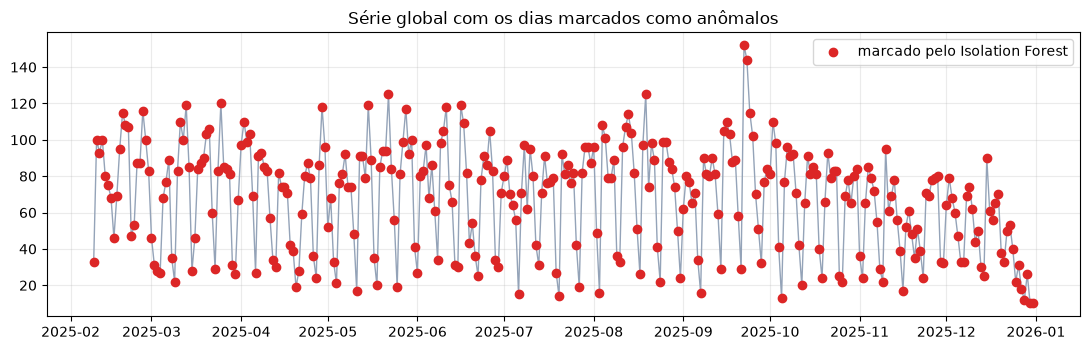

In [4]:
artefato = registry.carregar('model_anomalia')
contexto = features.historico_painel(base['painel']).dropna(subset=artefato['colunas'])
Z = artefato['escala'].transform(contexto[artefato['colunas']].replace([np.inf, -np.inf], 0).fillna(0))
pontuacao = -artefato['modelo'].score_samples(Z)

global_ = contexto['dimensao'] == 'global'
fig, eixo = plt.subplots(figsize=(11, 3.6))
eixo.plot(contexto.loc[global_, 'data'], contexto.loc[global_, 'lag_0'], color='#94a3b8', lw=1)
marcados = global_ & (pontuacao >= artefato['limiar'])
eixo.scatter(contexto.loc[marcados, 'data'], contexto.loc[marcados, 'lag_0'],
             color='#dc2626', zorder=5, label='marcado pelo Isolation Forest')
eixo.set_title('Série global com os dias marcados como anômalos'); eixo.legend()
plt.tight_layout(); plt.show()

In [5]:
achados = contexto.assign(pontuacao=pontuacao)
achados = achados[achados['pontuacao'] >= artefato['limiar']].nlargest(10, 'pontuacao')
achados[['data', 'dimensao', 'chave', 'pontuacao', 'lag_0', 'media_7',
         'criticos_media_7', 'mttr_medio_media_7']].round(2)

,data,dimensao,chave,pontuacao,lag_0,media_7,criticos_media_7,mttr_medio_media_7
8717,2025-09-24,global,,0.74,115.0,96.43,21.71,4706.69
8716,2025-09-23,global,,0.74,144.0,94.71,20.29,4277.25
8718,2025-09-25,global,,0.73,102.0,98.43,23.43,4841.47
8715,2025-09-22,global,,0.73,152.0,89.86,17.71,4783.17
8719,2025-09-26,global,,0.72,70.0,95.71,22.71,4396.73
8720,2025-09-27,global,,0.72,51.0,94.71,21.71,5038.55
8721,2025-09-28,global,,0.71,32.0,95.14,21.71,4886.45
8534,2025-03-25,global,,0.71,120.0,84.43,15.29,4965.05
8747,2025-10-24,global,,0.71,83.0,66.86,15.14,2245.10
8744,2025-10-21,global,,0.70,93.0,67.14,16.43,1950.50


A baixa concordância com o z-score não é defeito de nenhum dos dois: o z-score olha uma
variável (volume) contra a própria média; o Isolation Forest olha 15 variáveis ao mesmo tempo e
marca combinações — volume normal com severidade e MTTR altos, por exemplo — que uma régua
univariada não tem como enxergar. Os dois seguem na plataforma, cada um no seu papel.

## Classificador de pico

Aqui existe rótulo: o dia entrou ou não no topo 20% do volume histórico **daquela entidade**. O
limiar sai do percentil 80 calculado **apenas no treino** — calculá-lo sobre a série inteira
colocaria informação do teste dentro do próprio rótulo.

In [6]:
cartao_pico = train.treinar_pico(base)
print('Artefato gravado  :', cartao_pico['nome'], '->',
      registry.caminho_artefato(cartao_pico['nome']).name)
print('Algoritmo vencedor:', cartao_pico['algoritmo'])
print('Limiar de decisão :', cartao_pico['limiar_decisao'])
print('\nCalibração:', cartao_pico['calibracao'])
pd.DataFrame(cartao_pico['comparacao']).assign(
    **pd.DataFrame([c['metricas'] for c in cartao_pico['comparacao']]),
).drop(columns=['metricas']).sort_values('pr_auc', ascending=False)

Artefato gravado  : model_pico -> model_pico.pkl
Algoritmo vencedor: RandomForestClassifier (calibrado)
Limiar de decisão : 0.1746

Calibração: {'metodo': 'Platt (sigmoide) ajustada na validação', 'brier_antes': 0.17844, 'brier_depois': 0.09532, 'probabilidade_media_antes': 0.36938, 'probabilidade_media_depois': 0.17303, 'taxa_real_teste': 0.10455}


,candidato,tipo,algoritmo,vencedor,pr_auc,roc_auc,f1,recall
3,Random Forest,arvore,RandomForestClassifier,True,0.3317,0.7694,0.4240,0.6048
5,LightGBM,arvore,LGBMClassifier,False,0.3232,0.7779,0.4479,0.6394
2,Regressão logística,linear,LogisticRegression,False,0.3180,0.7673,0.4362,0.6573
4,XGBoost,arvore,XGBClassifier,False,0.3177,0.7716,0.4386,0.6555
0,Baseline (taxa histórica),baseline,RegraProbabilidade,False,0.1669,0.5008,0.2660,0.8249
1,Baseline (prevalência),baseline,DummyClassifier,False,0.1610,0.5000,0.0000,0.0000


In [7]:
pd.Series(
    {k: v for k, v in cartao_pico['metricas']['teste'].items() if k != 'matriz_confusao'},
).to_frame('teste')

,teste
accuracy,0.6377
precision,0.1802
recall,0.6948
f1,0.2862
brier,0.0953
limiar,0.1746
taxa_base,0.1045
positivos,1127.0000
n,10780.0000
roc_auc,0.7196


In [8]:
pd.DataFrame(cartao_pico['importancia_permutacao']).head(10)

,feature,descricao,queda_metrica,desvio
0,media_expandida,patamar histórico da entidade,0.08947,0.00692
1,feriado,é feriado,0.01874,0.00323
2,fim_de_semana,é fim de semana,0.00959,0.00353
3,dow,dia da semana previsto,0.00736,0.00355
4,dow_sin,dow sin,0.00466,0.00317
5,media_mesmo_dow_4,média do mesmo dia da semana nas últimas 4 sem...,0.00391,0.00158
6,mesmo_dow_3,"mesmo dia da semana, 3 semanas atrás",0.00360,0.00154
7,pos_feriado,dia seguinte a feriado,0.00358,0.00082
8,dim_categoria,entidade do tipo categoria,0.00336,0.00306
9,dim_item,entidade do tipo item,0.00311,0.00089
